Importing Libraries

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms
from torchvision import datasets, models

from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


Image visualization

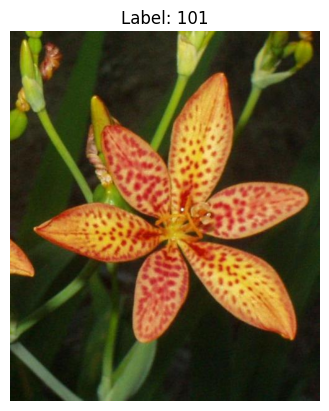

In [4]:
raw_dataset = datasets.Flowers102(
    root="./data",
    split="train",
    download=True
)

img, label = raw_dataset[1019]

plt.imshow(img)
plt.title(f"Label: {label}")
plt.axis("off")
plt.show()

Image Transformations

In [5]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std= [0.229, 0.224, 0.225]
    )
])

Visualization After Transformation

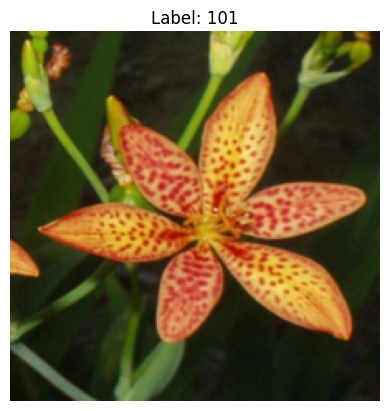

In [8]:
img, label = train_dataset[1019]

# undo normalization
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

img = img.permute(1,2,0).numpy()
img = img * std + mean
img = img.clip(0,1)

plt.imshow(img)
plt.title(f"Label: {label}")
plt.axis("off")
plt.show()

Loading Dataset

In [7]:
train_dataset = datasets.Flowers102(
    root='./data',
    split = 'train',
    download=True,
    transform = transform
)

val_dataset = datasets.Flowers102(
    root= './data',
    split= 'val',
    download=True,
    transform=transform
)

test_dataset = datasets.Flowers102(
    root= './data',
    split='test',
    download=True,
    transform=transform
)

In [9]:
print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))

1020
1020
6149


Creating Dataloaders

In [10]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [11]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


Loading pretrained model

In [12]:
model = models.resnet50(pretrained=True)

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [13]:
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [14]:
print(model.fc)

Linear(in_features=2048, out_features=1000, bias=True)


Freezing pretrained layers

In [15]:
for param in model.parameters():
    param.requires_grad = False

Replacing Final Layer

In [16]:
num_features = model.fc.in_features

model.fc = nn.Linear(num_features, 102)

In [17]:
model = model.to(device)

In [18]:
print(model.fc)

Linear(in_features=2048, out_features=102, bias=True)


Defining Loss Function

In [19]:
criterion = nn.CrossEntropyLoss()

Defining optimizer

In [20]:
optimizer = optim.Adam(
    model.fc.parameters(),
    lr = 0.001
)

epochs = 10

Training and Validation Loop

In [21]:
train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

In [22]:
for epoch in range(epochs):

    # -------- TRAINING --------
    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()


    train_loss = running_loss / len(train_loader)
    train_accuracy = 100 * correct / total

    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)


    # -------- VALIDATION --------
    model.eval()

    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()


    val_loss = val_loss / len(val_loader)
    val_accuracy = 100 * correct / total

    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)


    print(f"Epoch [{epoch+1}/{epochs}] | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Train Acc: {train_accuracy:.2f}% | "
          f"Val Acc: {val_accuracy:.2f}%")

Epoch [1/10] | Train Loss: 4.6361 | Val Loss: 3.4665 | Train Acc: 6.76% | Val Acc: 31.67%
Epoch [2/10] | Train Loss: 2.6644 | Val Loss: 2.3847 | Train Acc: 56.08% | Val Acc: 59.90%
Epoch [3/10] | Train Loss: 1.5560 | Val Loss: 1.7433 | Train Acc: 81.86% | Val Acc: 70.29%
Epoch [4/10] | Train Loss: 0.9747 | Val Loss: 1.4194 | Train Acc: 91.86% | Val Acc: 75.29%
Epoch [5/10] | Train Loss: 0.6747 | Val Loss: 1.1585 | Train Acc: 94.02% | Val Acc: 79.90%
Epoch [6/10] | Train Loss: 0.4835 | Val Loss: 1.0284 | Train Acc: 97.65% | Val Acc: 81.08%
Epoch [7/10] | Train Loss: 0.3479 | Val Loss: 0.9419 | Train Acc: 98.53% | Val Acc: 82.84%
Epoch [8/10] | Train Loss: 0.2789 | Val Loss: 0.8969 | Train Acc: 99.12% | Val Acc: 82.65%
Epoch [9/10] | Train Loss: 0.2361 | Val Loss: 0.8335 | Train Acc: 99.31% | Val Acc: 84.41%
Epoch [10/10] | Train Loss: 0.1776 | Val Loss: 0.8040 | Train Acc: 99.71% | Val Acc: 84.41%


Plotting Learning Curves

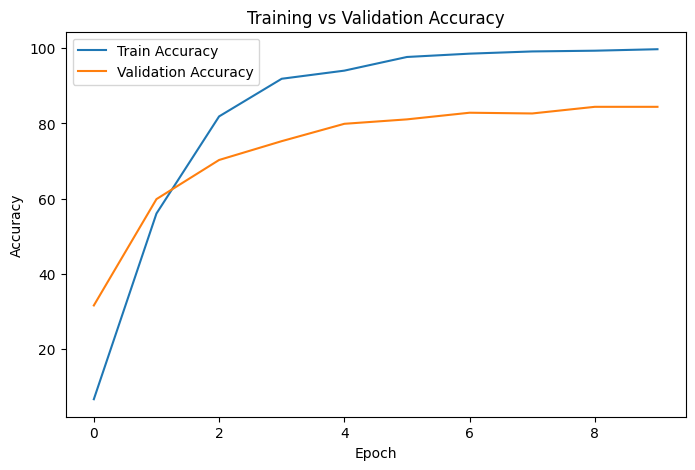

In [23]:
plt.figure(figsize=(8,5))

plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.show()

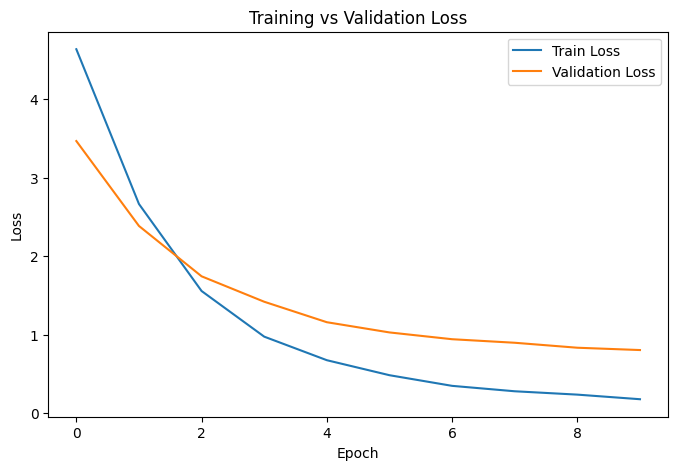

In [24]:
plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.show()

Test Accuracy

In [50]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    
    for images, labels in test_loader:
        
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images)
        
        _, predicted = torch.max(outputs, 1)
        
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy = 100 * correct / total

print("Test Accuracy:", test_accuracy)

Test Accuracy: 81.96454708082615


In [51]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

all_preds = []
all_labels = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

In [52]:
cm = confusion_matrix(all_labels, all_preds)

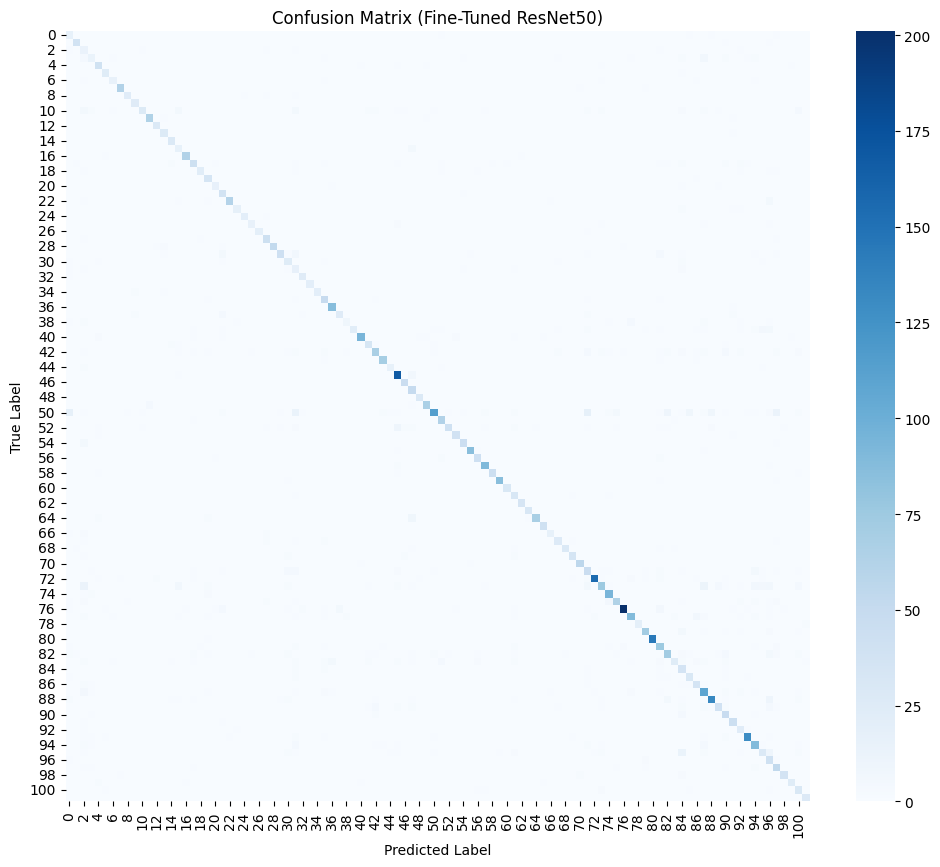

In [53]:
plt.figure(figsize=(12,10))

sns.heatmap(cm, cmap="Blues")

plt.title("Confusion Matrix (Fine-Tuned ResNet50)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [54]:
from sklearn.metrics import classification_report

print(classification_report(all_labels, all_preds, digits=4))

              precision    recall  f1-score   support

           0     0.3265    0.8000    0.4638        20
           1     0.9268    0.9500    0.9383        40
           2     0.1772    0.7000    0.2828        20
           3     0.5417    0.3611    0.4333        36
           4     0.7692    0.8889    0.8247        45
           5     0.8571    0.9600    0.9057        25
           6     0.7895    0.7500    0.7692        20
           7     0.9692    0.9692    0.9692        65
           8     0.9200    0.8846    0.9020        26
           9     0.8621    1.0000    0.9259        25
          10     0.9000    0.4030    0.5567        67
          11     0.9412    0.9552    0.9481        67
          12     0.9062    1.0000    0.9508        29
          13     0.8182    0.9643    0.8852        28
          14     0.8286    1.0000    0.9062        29
          15     0.4706    0.7619    0.5818        21
          16     0.9692    0.9692    0.9692        65
          17     0.7963    

Finetuning ResNet50

In [26]:
model2 = models.resnet50(pretrained=True)

In [27]:
for param in model2.parameters():
    param.requires_grad = False

In [28]:
print(model2)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

Replacing final layer

In [29]:
num_features = model2.fc.in_features
model2.fc = nn.Linear(num_features, 102)

In [30]:
print(model2.fc)

Linear(in_features=2048, out_features=102, bias=True)


Unfreezing last residual block

In [31]:
for param in model2.layer4.parameters():
    param.requires_grad = True

In [32]:
model2 = model2.to(device)

In [33]:
criterion2 = nn.CrossEntropyLoss()

Optimizer with smaller lr

In [34]:
optimizer2 = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model2.parameters()),
    lr = 0.0001
)

In [35]:
epochs2 = 5

In [36]:
train_losses2 = []
val_losses2 = []

train_accuracies2 = []
val_accuracies2 = []

for epoch in range(epochs2):
    model2.train()

    running_loss = 0
    correct = 0
    total =0

    for images, labels in train_loader:
        images=images.to(device)
        labels = labels.to(device)

        optimizer2.zero_grad()

        outputs = model2(images)

        loss = criterion2(outputs, labels)

        loss.backward()

        optimizer2.step()

        running_loss += loss.item()

        _, predicted =torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_accuracy = 100 * correct/total

    train_losses2.append(train_loss)
    train_accuracies2.append(train_accuracy)


    model2.eval()

    val_loss = 0
    correct= 0
    total = 0

    with torch.no_grad():
        for images,labels in val_loader:    
            images = images.to(device)
            labels = labels.to(device)

            outputs =model2(images)

            loss = criterion2(outputs, labels)

            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss = val_loss / len(val_loader)
    val_accuracy = 100 * correct/total

    val_losses2.append(val_loss)
    val_accuracies2.append(val_accuracy)

    print(f"Epoch [{epoch + 1}/{epochs2}] |"
          f"Train Loss:{train_loss:.4f} |"
          f"Val Loss:{val_loss:.4f} |"
          f"Train Accuracy:{train_accuracy:.4f} |"
          f'Val Accuracy:{val_accuracy:.4f}'
          )



Epoch [1/5] |Train Loss:4.1812 |Val Loss:3.2201 |Train Accuracy:18.8235 |Val Accuracy:55.9804
Epoch [2/5] |Train Loss:2.5397 |Val Loss:2.1683 |Train Accuracy:83.6275 |Val Accuracy:77.0588
Epoch [3/5] |Train Loss:1.3501 |Val Loss:1.4572 |Train Accuracy:94.7059 |Val Accuracy:84.4118
Epoch [4/5] |Train Loss:0.6123 |Val Loss:1.0227 |Train Accuracy:98.8235 |Val Accuracy:89.5098
Epoch [5/5] |Train Loss:0.2623 |Val Loss:0.8212 |Train Accuracy:99.8039 |Val Accuracy:91.1765


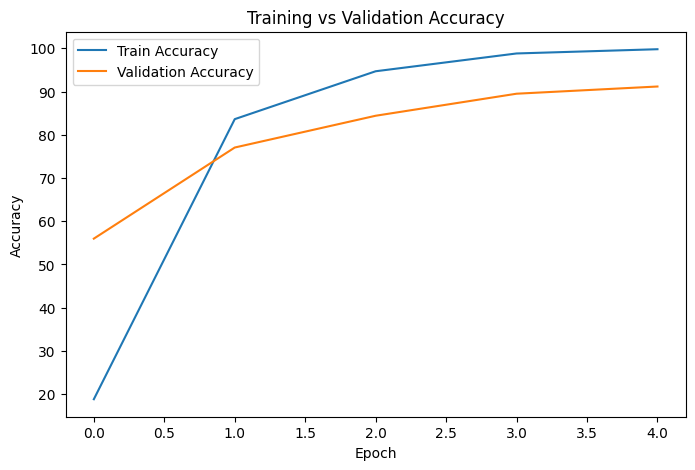

In [37]:
plt.figure(figsize=(8,5))

plt.plot(train_accuracies2, label="Train Accuracy")
plt.plot(val_accuracies2, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.show()

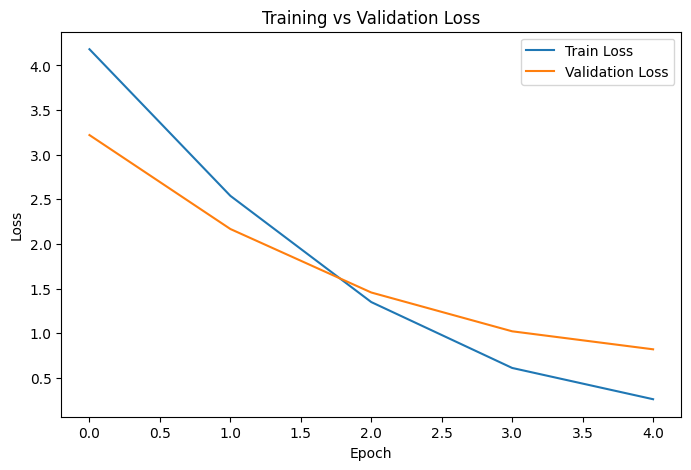

In [38]:
plt.figure(figsize=(8,5))

plt.plot(train_losses2, label="Train Loss")
plt.plot(val_losses2, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.show()

In [39]:
model2.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model2(images)

        _, predicted = torch.max(outputs,1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy2 = 100 * correct / total

print("Fine-tuned Test Accuracy:", test_accuracy2)

Fine-tuned Test Accuracy: 87.26622214994308


In [55]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

all_preds = []
all_labels = []

model2.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model2(images)

        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

In [56]:
cm = confusion_matrix(all_labels, all_preds)

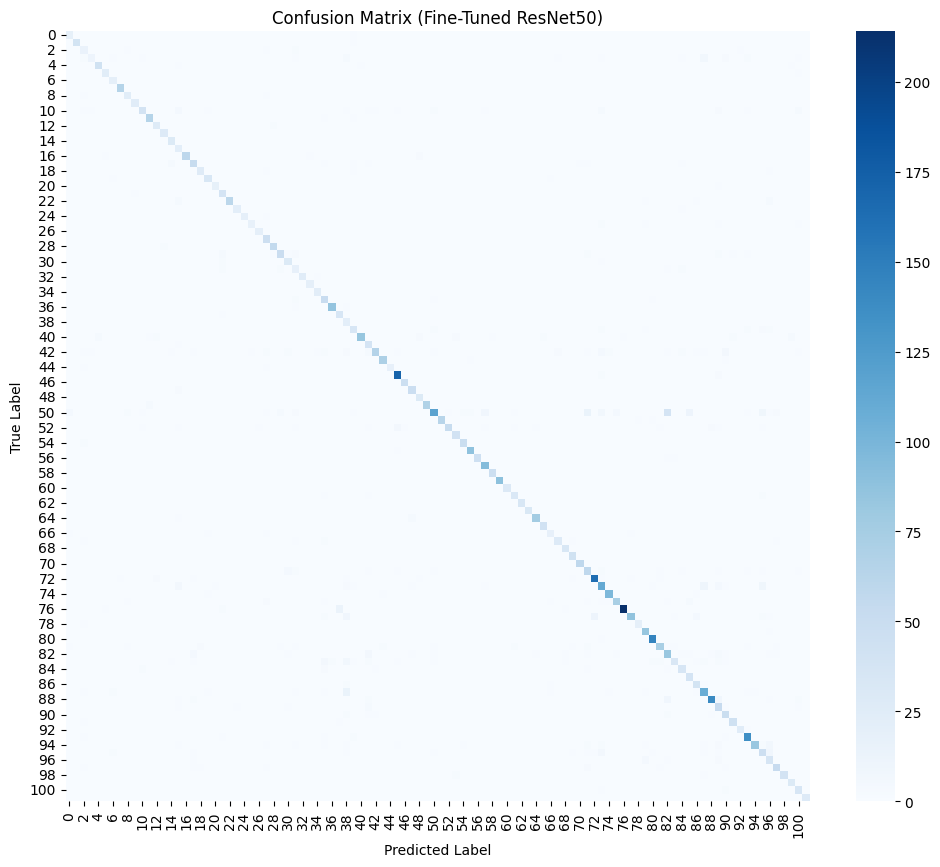

In [57]:
plt.figure(figsize=(12,10))

sns.heatmap(cm, cmap="Blues")

plt.title("Confusion Matrix (Fine-Tuned ResNet50)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [59]:
from sklearn.metrics import classification_report

print(classification_report(all_labels, all_preds, digits=4))

              precision    recall  f1-score   support

           0     0.7308    0.9500    0.8261        20
           1     1.0000    0.9750    0.9873        40
           2     0.5172    0.7500    0.6122        20
           3     0.8462    0.3056    0.4490        36
           4     0.9130    0.9333    0.9231        45
           5     0.9231    0.9600    0.9412        25
           6     0.7692    1.0000    0.8696        20
           7     0.9848    1.0000    0.9924        65
           8     0.8276    0.9231    0.8727        26
           9     0.9615    1.0000    0.9804        25
          10     0.8889    0.5970    0.7143        67
          11     0.9286    0.9701    0.9489        67
          12     0.8438    0.9310    0.8852        29
          13     0.9333    1.0000    0.9655        28
          14     0.8286    1.0000    0.9062        29
          15     0.4565    1.0000    0.6269        21
          16     1.0000    0.9231    0.9600        65
          17     0.8000    